# PROC G3D를 이용한 학생 시험 성과의 3D 곡면·산점도 시각화

## 핵심 요약

이 노트북은 **PROC G3D**를 사용하여 교육 분석 환경에서 두 가지 수업 개입 요인이
학생 성과를 함께 어떻게 형성하는지 시각화합니다. 완전 요인 격자가 주간 학습시간
(0에서 20)과 이전 학기 GPA(0에서 4)에 걸친 예측 시험 점수의 매끄러운 **곡면
(surface)**을 만들어 내고, 100명의 합성 학생 코호트는 성취 등급별로 분할된
**3D 산점도(scatter)** 패널로 표현됩니다.

적합된 곡면은 학습시간 0에서 약 26점이던 예측 점수가 약 99점의 상한까지
올라가며, 학습시간이 대략 10시간을 넘어서면 완만해집니다 — 이는 모델이
담고 있는 수확체감의 능선입니다. 학생 패널은 개인 수준에서도 같은 패턴을
확인해 줍니다: 85점 이상을 받은 20명의 **우수(Honors)** 학생은 GPA가 높고
학습시간도 많은 구간에 자리하며, 33명의 **위험군(AtRisk)** 학생은 노력과
GPA가 모두 낮은 영역에 몰려 있습니다. 그 구간을 WHERE로 걸러낸 뷰는 35명의
학생을 분리해 내는데, 이들에게는 학습시간을 조금만 늘려도 가장 큰 한계
이득이 돌아갑니다.


## 데이터 원본

모든 데이터는 `call streaminit()`과 `rand()`로 인라인 생성되며, 외부 파일이나
네트워크 접근은 없습니다.

**`score_grid`** — 반응 곡면을 만들어 내는 완전 요인 격자 (학습시간 x 이전 GPA
셀당 한 행, 총 99행).

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `study_hours` | Num | 주간 자기학습 시간, 0에서 20까지 2 단위 (X축) |
| `prior_gpa` | Num | 0–4 척도의 이전 학기 GPA, 0에서 4까지 0.5 단위 (Y축) |
| `pred_score` | Num | 포화 반응 모형으로부터 산출된 예측 기말고사 점수 0–100 (Z축) |

**`students`** — 산점도를 위한 합성 개별 학생 코호트 (100행).

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `student_id` | Num | 순차적 학생 식별자 |
| `study_hours` | Num | 관측된 주간 학습시간 (X축) |
| `prior_gpa` | Num | 관측된 이전 학기 GPA (Y축) |
| `exam_score` | Num | 관측된 기말고사 점수 0–100 (Z축) |
| `cohort` | Char | 등록 학기, `가을` 또는 `봄` |
| `band` | Char | 성취 등급: `우수` (85 이상), `통과` (65–84), `위험군` (65 미만) |

이 격자는 의도적으로 99개 셀로 구성되어 0–20 학습시간과 0–4 GPA 범위 전체를
포괄하면서도 이 환경의 100관측값 한도 이내에 머무릅니다. 11 x 9 격자는 어느
축도 잘라내지 않으면서 곡면을 매끄럽게 유지합니다.


# PROC G3D를 이용한 학생 시험 성과 시각화

교육 연구자들은 흔히 두 가지 조정 가능한 요인이 결과를 함께 어떻게 이끄는지
알고 싶어 합니다. 여기서는 이렇게 묻습니다: *주간 학습시간과 학생의 이전
GPA가 결합하여 기말고사 성과를 어떻게 형성하는가?*

2차원 차트로는 상호작용 곡면을 보여줄 수 없습니다. **PROC G3D**는 `y*x=z`
표기법의 변수로부터 진짜 3차원 그래프를 그리며, 여기서 X와 Y는 수평면을
가로지르고 Z는 수직으로 올라갑니다. 우리는 두 가지 기능을 사용합니다:

- **PLOT** — 두 예측변수의 완전한 격자에 대한 연속적인 반응 **곡면**.
- **SCATTER** — 개별 학생을 3D 기호로 표시. 성취 등급별로 하나씩 패널을
  그리며, 각 패널은 고유한 마커 색상과 모양을 가져 세 결과 등급을 쉽게
  비교할 수 있게 합니다.

아래의 모든 내용은 인라인으로 생성된 합성 데이터로 실행되므로, 이 노트북은
완전히 독립적입니다.


## 1단계 — 반응 곡면 격자 생성

G3D 곡면 그림은 상당히 완전한 격자를 필요로 합니다: 최소 절반의 X-Y 셀에서
결측이 아닌 Z 값이 있어야 합니다. `study_hours`(0에서 20까지 2 단위)와
`prior_gpa`(0에서 4까지 0.5 단위)에 대해 두 개의 `DO` 반복문을 중첩하여
두 축을 완전히 포괄하는 11 x 9 격자(99개 셀)로 *완전한* 격자를 보장합니다.

예측 점수는 그럴듯한 포화 모형을 따릅니다: 학습시간이 많아질수록 수익은
줄어들고, 이전 GPA는 대략 선형으로 기여하며, 두 요인은 상호작용합니다
(우수한 학생일수록 학습시간을 점수로 더 효율적으로 전환합니다).
`rand('NORMAL')`의 작은 재현 가능한 잡음은 곡면이 지나치게 이상적으로
보이지 않게 합니다. `call streaminit()`이 시드를 고정하여 격자가 재현
가능하도록 합니다.


In [1]:
데이터 score_grid;
   호출 streaminit(20260531);
   반복 study_hours = 0 까지 20 기준 2;     /* 11 values: full 0-20 range */
      반복 prior_gpa = 0 까지 4 기준 0.5;   /* 9 values  -> 99 grid cells */
         /* saturating return to study hours */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* prior achievement and an interaction term */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         만약 pred_score > 100 이면 pred_score = 100;
         만약 pred_score < 0   이면 pred_score = 0;
         출력;
      종료;
   종료;
   유지 study_hours prior_gpa pred_score;
   라벨 study_hours='주간 학습시간' prior_gpa='이전 학기 GPA' pred_score='예측 시험 점수';
실행;

처리 평균 데이터=score_grid n MIN mean MAX maxdec=1;
   변수 study_hours prior_gpa pred_score;
   라벨 study_hours='주간 학습시간' prior_gpa='이전 학기 GPA' pred_score='예측 시험 점수';
실행;


                                                  The MEANS Procedure

 Variable     Label                       N     Minimum        Mean     Maximum
 ------------------------------------------------------------------------------
 study_hours  주간 학습시간                    99         0.0        10.0        20.0
 prior_gpa    이전 학기 GPA                  99         0.0         2.0         4.0
 pred_score   예측 시험 점수                   99        25.7        70.0        98.7
 ------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 2단계 — 기본 반응 곡면 그리기

완전한 격자가 준비되면, 가장 단순한 호출은 프로시저 기본값으로 곡면을
그립니다. `PLOT y*x=z` 구문은 `prior_gpa`를 Y축에, `study_hours`를 X축에,
예측 점수를 Z축에 매핑합니다.

`LABEL` 문으로 축에 라벨을 붙이고, 전역 `TITLE`/`FOOTNOTE` 문으로 제목과
각주를 설정하여 그래프가 명료하게 읽히도록 합니다.


                                                    예측 기말고사 점수 반응 곡면                                                    
                                                 주간 학습시간과 이전 학기 GPA의 영향                                                 

PROC G3D Output
Data: score_grid

Variables: 주간 학습시간, 이전 학기 GPA, 예측 시험 점수

            주간 학습시간          이전 학기 GPA              예측 시험 점수
-------------------  -----------------  --------------------
                  0                  0         25.7031536911
                  0                0.5         28.9516502743
                  0                  1         32.3400787822
                  0                1.5         36.8265757618
                  0                  2         40.7806886968
                  0                2.5           42.61364606
                  0                  3         49.4289293966
                  0                3.5         52.6020716414
                  0                  4         55.6325677612
           


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to 예측 기말고사 점수 반응 곡면.
NOTE: Option TITLE2 changed to 주간 학습시간과 이전 학기 GPA의 영향.
NOTE: Option FOOTNOTE changed to 합성 교육분석 데이터 .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


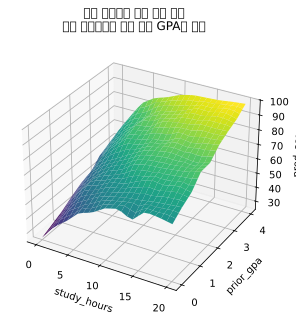

In [2]:
GOPTIONS reset=GLOBAL BORDER;

제목 '예측 기말고사 점수 반응 곡면';
title2 '주간 학습시간과 이전 학기 GPA의 영향';
footnote j=r '합성 교육분석 데이터 ';

처리 g3d 데이터=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         pred_score  = '예측 시험 점수';
실행;
QUIT;


## 3단계 — 보기 및 축 옵션으로 곡면 다듬기

몇 가지 옵션만으로 곡면의 가독성이 훨씬 좋아집니다:

- **ROTATE=**와 **TILT=**는 보는 각도(Z축 둘레의 회전 각도와 시청자 쪽으로의
  기울기)를 설정합니다.
- **XYTYPE=2**는 Y축과 평행한 곡면선을 그려 학습시간에 따라 점수가 올라가는
  모습을 강조합니다.
- **SIDE**는 옆벽을 추가해 단단하고 조각된 듯한 모습을 줍니다.
- **GRID**는 주요 눈금에 참조선을 추가합니다.
- **ZMIN=/ZMAX=**와 **ZTICKNUM=** 계열은 점수 축을 0–100 전체 범위로
  고정하여 곡면이 시각적으로 과장되지 않게 하며, **XTICKNUM=/YTICKNUM=**은
  바닥면 눈금을 제어합니다.
- **NAME=**과 **DESCRIPTION=**은 출력 카탈로그에서 그래프에 라벨을 붙입니다.


                                                  예측 시험 점수 곡면 (스타일 적용)                                                  
                                                   회전, 기울임, 축 스케일 조정                                                    

PROC G3D Output
Data: score_grid

Variables: 주간 학습시간, 이전 학기 GPA, 예측 시험 점수

            주간 학습시간          이전 학기 GPA              예측 시험 점수
-------------------  -----------------  --------------------
                  0                  0         25.7031536911
                  0                0.5         28.9516502743
                  0                  1         32.3400787822
                  0                1.5         36.8265757618
                  0                  2         40.7806886968
                  0                2.5           42.61364606
                  0                  3         49.4289293966
                  0                3.5         52.6020716414
                  0                  4         55.6325677612
           


NOTE: Option TITLE changed to 예측 시험 점수 곡면 (스타일 적용).
NOTE: Option TITLE2 changed to 회전, 기울임, 축 스케일 조정.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


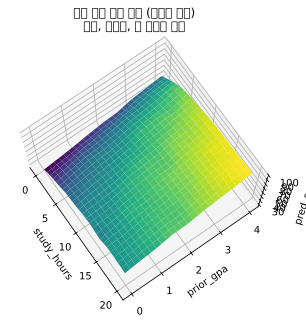

In [3]:
제목 '예측 시험 점수 곡면 (스타일 적용)';
title2 '회전, 기울임, 축 스케일 조정';

처리 g3d 데이터=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Styled exam-score response surface";
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         pred_score  = '예측 시험 점수';
실행;
QUIT;


## 4단계 — 여러 시야각에서 곡면 비교

3D 곡면은 자신의 봉우리 뒤에 구조를 숨길 수 있으므로, 같은 곡면을 여러
회전각에서 렌더링하는 것이 도움이 됩니다. 여기서는 고정된 기울기를 공유하되
**ROTATE=** 각도를 30, 90, 150도로 바꿔가며 세 번의 PROC G3D 단계를
실행하여, 능선을 정면·측면·후면에서 살펴볼 수 있게 합니다.


                                                         반응 곡면                                                          
                                                  ROTATE = 30 (기울기 고정)                                                  

PROC G3D Output
Data: score_grid

Variables: 주간 학습시간, 이전 학기 GPA, 예측 시험 점수

            주간 학습시간          이전 학기 GPA              예측 시험 점수
-------------------  -----------------  --------------------
                  0                  0         25.7031536911
                  0                0.5         28.9516502743
                  0                  1         32.3400787822
                  0                1.5         36.8265757618
                  0                  2         40.7806886968
                  0                2.5           42.61364606
                  0                  3         49.4289293966
                  0                3.5         52.6020716414
                  0                  4         55.6325677612
           


NOTE: Option TITLE changed to 반응 곡면.
NOTE: Option TITLE2 changed to ROTATE = 30 (기울기 고정).
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to 반응 곡면.
NOTE: Option TITLE2 changed to ROTATE = 90 (기울기 고정).
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to 반응 곡면.
NOTE: Option TITLE2 changed to ROTATE = 150 (기울기 고정).
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


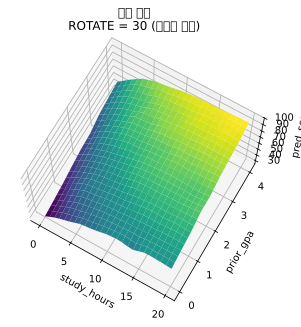

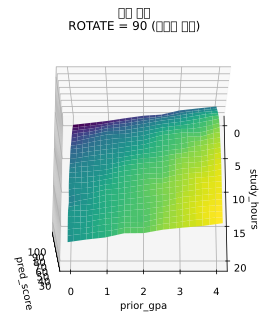

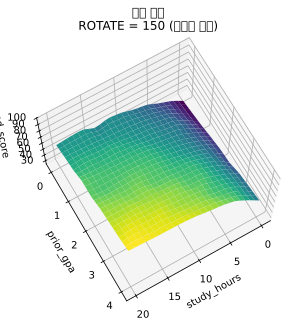

In [4]:
%macro angle(deg);
   제목 '반응 곡면';
   title2 "ROTATE = &deg (기울기 고정)";
   처리 g3d 데이터=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      라벨 study_hours = '주간 학습시간'
            prior_gpa   = '이전 학기 GPA'
            pred_score  = '예측 시험 점수';
   실행;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## 5단계 — 합성 학생 코호트 생성

곡면은 모형일 뿐이며, 실제 학생들은 그 주위에 흩어져 있습니다. 이제 두
등록 학기(`가을`, `봄`)에서 추출한 100명의 개별 학생을 시뮬레이션합니다.
각 학생은 관측된 학습시간, 이전 GPA, 그리고 같은 반응 로직에 더 큰 개인
편차를 더해 생성한 잡음 섞인 실제 시험 점수를 가집니다.

그런 다음 시험 점수로부터 성취 **등급**을 도출합니다: `우수`(85점 이상),
`통과`(65에서 84점), `위험군`(65점 미만). 아래의 PROC FREQ 교차표는 두
학기에 걸쳐 등급이 어떻게 분포하는지 보여줍니다. `rand('UNIFORM')`과
`rand('NORMAL')`이 무작위성을 제공하며, 시드는 재현성을 유지합니다.


                                                         반응 곡면                                                          
                                                 ROTATE = 150 (기울기 고정)                                                  

                                                   The FREQ Procedure

                              Cumulative
성취 등급            Frequency    Frequency
-------------------------------------------
우수                      20           20
위험군                     33           53
통과                      47          100

Table of 등록 학기 by 성취 등급

등록 학기         |        우수 |       위험군 |        통과 |      Total
--------------+-----------+-----------+-----------+-----------
가을            |         6 |        15 |        20 |         41
--------------+-----------+-----------+-----------+-----------
봄             |        14 |        18 |        27 |         59
--------------+-----------+-----------+-----------+-----------
Total         |        20 |        33


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


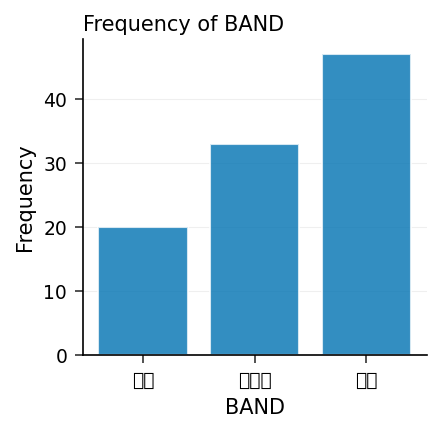

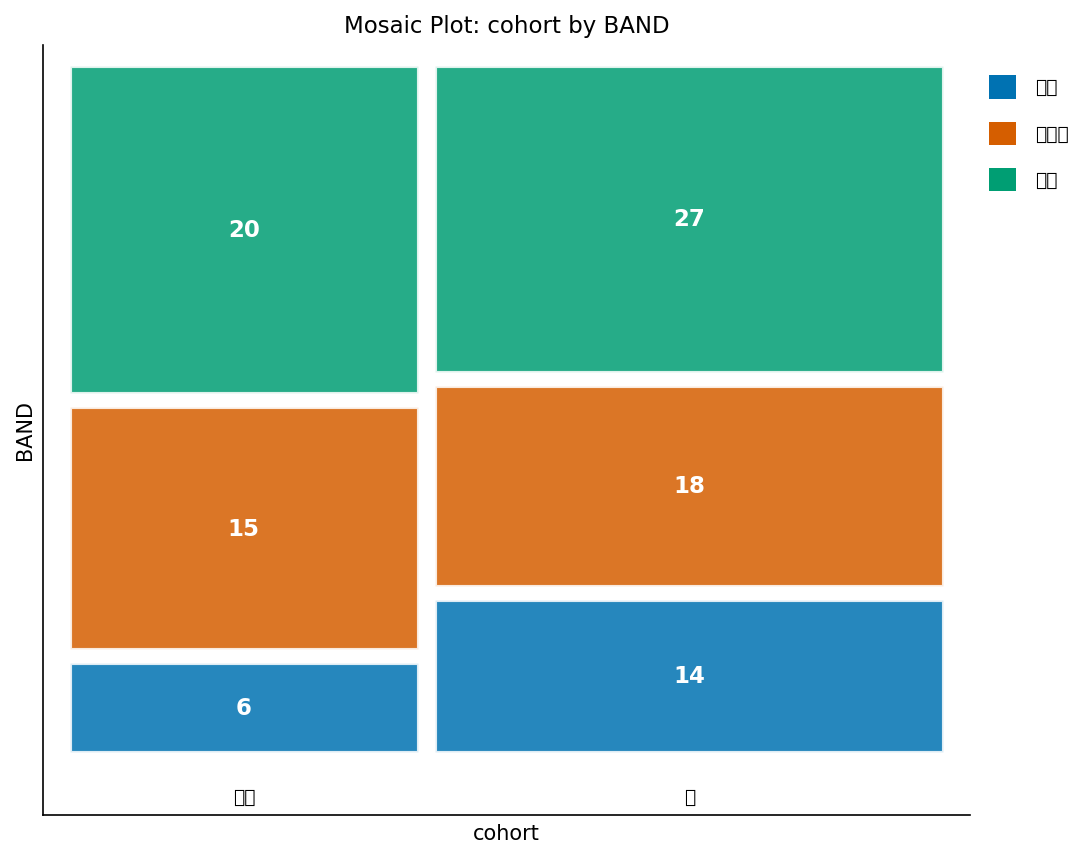

In [5]:
데이터 students;
   호출 streaminit(99001);
   길이 cohort $16 BAND $16;
   반복 student_id = 1 까지 100;
      만약 rand('UNIFORM') < 0.5 이면 cohort = '가을';
      아니면 cohort = '봄';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      만약 exam_score > 100 이면 exam_score = 100;
      만약 exam_score < 0   이면 exam_score = 0;

      만약 exam_score >= 85 이면 BAND = '우수';
      아니면 만약 exam_score >= 65 이면 BAND = '통과';
      아니면 BAND = '위험군';

      출력;
   종료;
   유지 student_id cohort study_hours prior_gpa exam_score BAND;
   라벨 cohort='등록 학기' BAND='성취 등급' study_hours='주간 학습시간'
         prior_gpa='이전 학기 GPA' exam_score='기말고사 점수';
실행;

처리 빈도 데이터=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   라벨 BAND='성취 등급' cohort='등록 학기';
실행;


## 6단계 — 성취 등급별 3D 산점도 패널로 학생 그리기

**SCATTER** 문은 각 학생을 3D 기호로 배치합니다. 세 성취 등급을 읽기
쉽게 하기 위해 등급별로 하나씩 패널을 그리며, 각 패널은 **WHERE**로
걸러지고 고유한 리터럴 **COLOR=**와 **SHAPE=**를 가집니다: *우수*는
초록 다이아몬드(`SHAPE=diamond`), *통과*는 파란 마커(`SHAPE=club`),
*위험군*은 빨간 마커(`SHAPE=spade`)입니다. **SIZE=**는 마커를 확대하고,
**GRID**는 바닥 참조선을 추가하며, **NONEEDLE**은 수직 낙하선을 제거하고,
**ZMIN=/ZMAX=**는 모든 패널을 동일한 0–100 점수 축에 고정하여 세 뷰를
직접 비교할 수 있게 합니다.

각 등급은 자신만의 PROC G3D 단계를 가지므로 WHERE 필터가 깔끔하게
적용되고 마커 스타일도 명확합니다.


                                                        우수 등급 학생                                                        
                                                     기말고사 점수 85점 이상                                                     

PROC G3D Output
Data: students

Variables: student_id, 등록 학기, 주간 학습시간, 이전 학기 GPA, 기말고사 점수, 성취 등급

student_id          등록 학기              주간 학습시간          이전 학기 GPA              기말고사 점수          성취 등급
----------  -------------  -------------------  -----------------  -------------------  -------------
         2              봄        19.2134883194       2.6467742616        90.3663886999             우수
         5              봄        15.5520919174       2.7102003827        94.9419468332             우수
        10              봄        14.2302640951       3.8791496428                  100             우수
        17              봄        13.7403346635       2.7462821708        89.6648779222             우수
        25             가을        18.7592154739 


NOTE: Option FOOTNOTE changed to 합성 학생 100명 코호트 기준 .
NOTE: Option TITLE changed to 우수 등급 학생.
NOTE: Option TITLE2 changed to 기말고사 점수 85점 이상.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to 통과 등급 학생.
NOTE: Option TITLE2 changed to 기말고사 점수 65점에서 84점.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to 위험군 학생.
NOTE: Option TITLE2 changed to 기말고사 점수 65점 미만.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


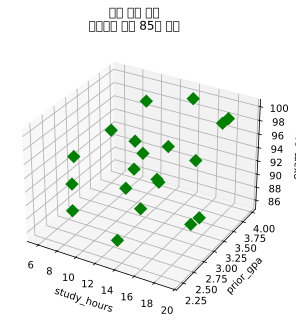

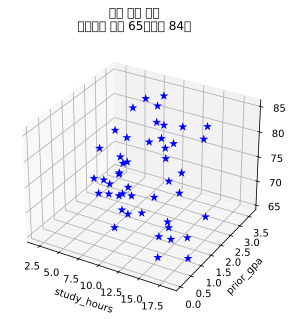

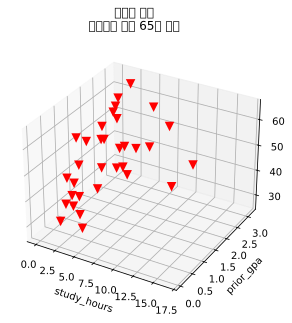

In [6]:
footnote j=r '합성 학생 100명 코호트 기준 ';

/* Honors (exam_score >= 85): green diamonds */
제목 '우수 등급 학생';
title2 '기말고사 점수 85점 이상';
처리 g3d 데이터=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Honors students";
   조건 BAND = '우수';
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         exam_score  = '기말고사 점수';
실행;
QUIT;

/* Pass (65 <= exam_score < 85): blue clubs */
제목 '통과 등급 학생';
title2 '기말고사 점수 65점에서 84점';
처리 g3d 데이터=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Pass students";
   조건 BAND = '통과';
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         exam_score  = '기말고사 점수';
실행;
QUIT;

/* AtRisk (exam_score < 65): red spades */
제목 '위험군 학생';
title2 '기말고사 점수 65점 미만';
처리 g3d 데이터=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="At-risk students";
   조건 BAND = '위험군';
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         exam_score  = '기말고사 점수';
실행;
QUIT;


## 7단계 — 등록 학기별(BY 그룹) 산점도 분리

프로그램 책임자는 종종 같은 뷰를 학기별로 나눈 것을 필요로 합니다. **BY**
문은 학기당 하나의 산점도를 만듭니다. G3D는 BY 그룹 데이터가 정렬되어
있기를 기대하므로, 먼저 PROC SORT로 정렬합니다. 그런 다음 각 학기는
공유된 0–100 점수 축 위에 라벨이 붙은 자신만의 3D 산점도를 가지게 되어,
가을과 봄의 분포를 나란히 비교하기 쉬워집니다.


                                                      등록 학기별 시험 성과                                                      
                                                   학기별 3D 산점도 (가을, 봄)                                                   

PROC G3D Output
Data: students_sorted

Variables: student_id, 등록 학기, 주간 학습시간, 이전 학기 GPA, 기말고사 점수, 성취 등급

student_id          등록 학기              주간 학습시간          이전 학기 GPA              기말고사 점수          성취 등급
----------  -------------  -------------------  -----------------  -------------------  -------------
        52             가을        15.2586640362       0.4602308374        55.5186804916            위험군
        13             가을         5.8493366471       1.8449001873        70.6084324429             통과
        15             가을         5.5070892672       1.4478111608        70.0069314398             통과
        22             가을         0.0365105382       1.3187236247        35.9197853017            위험군
        24             가을        18.3158


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 등록 학기별 시험 성과.
NOTE: Option TITLE2 changed to 학기별 3D 산점도 (가을, 봄).
NOTE: Option FOOTNOTE changed to 학기당 하나의 패널 .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


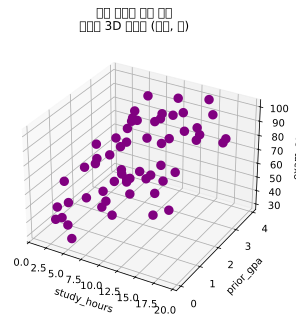

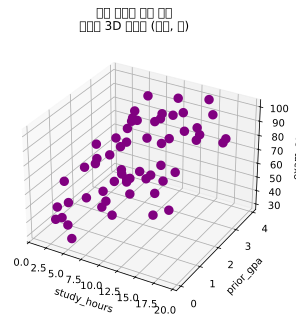

In [7]:
처리 정렬 데이터=students out=students_sorted;
   기준 cohort;
실행;

제목 '등록 학기별 시험 성과';
title2 '학기별 3D 산점도 (가을, 봄)';
footnote j=r '학기당 하나의 패널 ';

처리 g3d 데이터=students_sorted;
   기준 cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         exam_score  = '기말고사 점수';
실행;
QUIT;


## 8단계 — WHERE로 위험군 영역에 집중

개입 계획을 위해 가장 실행 가능한 뷰는 곡면의 좌측 하단입니다: 학습시간이
적당히 적고(8시간 이하) 이전 GPA도 낮은(2.5 이하) 학생들입니다. **WHERE**
문은 그리기 전에 산점도를 이 영역으로 부분집합화합니다. 목록을 보면 이
구석에 100명 중 35명이 있으며 — 그중 22명은 이미 *위험군*입니다 — 상담자는
어떤 어려움을 겪는 학생이 기대치에서 가장 크게 벗어나 있는지 정확히 볼 수
있습니다.


                                              개입 집중 대상: 낮은 학습시간·낮은 GPA 학생                                               
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, 등록 학기, 주간 학습시간, 이전 학기 GPA, 기말고사 점수, 성취 등급

student_id          등록 학기              주간 학습시간          이전 학기 GPA              기말고사 점수          성취 등급
----------  -------------  -------------------  -----------------  -------------------  -------------
         1             가을         4.9780700766        1.072086769         59.409228777            위험군
         7              봄         7.9015823058       1.6623636789        66.9055021729             통과
         9              봄         2.5008494545       0.3621033759        48.1183184446            위험군
        11              봄         7.1907276895       2.1821388818         79.351887155             통과
        13             가을         5.8493366471 


NOTE: Option TITLE changed to 개입 집중 대상: 낮은 학습시간·낮은 GPA 학생.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to 니들선이 각 마커를 학습시간 x GPA 바닥으로 내립니다 .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


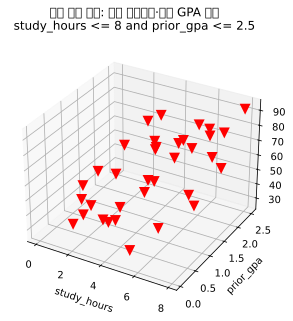

In [8]:
제목 '개입 집중 대상: 낮은 학습시간·낮은 GPA 학생';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r '니들선이 각 마커를 학습시간 x GPA 바닥으로 내립니다 ';

처리 g3d 데이터=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   조건 study_hours <= 8 그리고 prior_gpa <= 2.5;
   라벨 study_hours = '주간 학습시간'
         prior_gpa   = '이전 학기 GPA'
         exam_score  = '기말고사 점수';
실행;
QUIT;


## 결과 해석

**반응 곡면**(2–4단계)은 뚜렷한 포화 능선을 보여줍니다. 99셀 격자 전체에서
예측 점수는 약 26점(학습시간 0, GPA 0)에서 약 99점(학습시간 높음, GPA 높은
구석)까지 이어지며, 격자 전체 평균은 70에 가깝습니다. 학습시간 축을 따라
읽으면 점수는 0에서 약 10시간까지 가파르게 오르다가 추가 시간이 수확체감을
낳으면서 완만해집니다. GPA 축을 따라 읽으면 이전 성취가 곡면 전체를
위로 밀어 올립니다. 상호작용항은 우수한 학생일수록 학습시간의 보상을
조금 더 가파르게 만들며, 이 때문에 곡면은 평평한 평면으로 오르는 대신
먼 구석을 향해 기울어집니다.

**학생 패널**(6–7단계)은 이 모형이 개인 수준에서도 성립함을 확인해
줍니다. 100명의 코호트는 *우수* 20명, *통과* 47명, *위험군* 33명으로
나뉩니다. 등급별 패널에서 20개의 초록 *우수* 다이아몬드는 — 모두 85점
이상이며 — 이전 GPA 2.2 이상, 주간 학습시간 약 6시간 이상에 자리하며
바닥면의 우측 상단에 몰려 있습니다. 33개의 빨간 *위험군* 마커는 저노력·
저GPA 영역, 즉 곡면의 골짜기에 정확히 몰려 있습니다. 학기별로 나누어
보면 가을(41명)과 봄(59명)의 분포가 대체로 비슷하여, 결과가 등록
시기보다는 두 요인에 의해 좌우됨을 시사합니다.

**WHERE로 걸러낸 뷰**(8단계)는 개입 대상 집단을 분리해 냅니다: 학습시간
8시간 이하이면서 GPA 2.5 이하인 35명의 학생입니다. 그중 22명은 이미
*위험군*이고 단 한 명만 *우수*에 도달합니다. 이 구석 안에서도 실제 점수는
학습시간에 따라 눈에 띄게 상승하는데 — 이는 구조화된 학습시간을 조금만
늘려도 가장 필요한 곳에서 가장 큰 한계 이득을 얻는다는 구체적이고 시각적인
근거입니다.

종합하면, PROC G3D는 두 요인 상호작용 모형을 교육 프로그램을 위한 직관적이고
의사결정 가능한 그림으로 바꾸어 줍니다: 점수의 상한이 어디에 있는지, 누가
그에 못 미치는지, 그리고 어디에 지도 노력을 쏟아야 가장 큰 성과를 거두는지
보여 줍니다.

> **구현 참고.** SAS/GRAPH는 하나의 SCATTER 문에서 관측값별 변수로 각 마커의
> 색상과 모양을 지정하는 것도 허용합니다(`COLOR=<charvar>`, `SHAPE=<charvar>`).
> 이 관측값별 방식은 아직 이 엔진에서 렌더링되지 않으므로, 이 노트북은 대신
> 등급별로 리터럴 색상을 지정한 패널을 하나씩 그립니다 — 동등하면서도 완전히
> 동작하는 표현 방식입니다. 이 공백은 보관된 회귀 테스트
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`로 추적됩니다.
